# Week 5 Lab: Function Approximation with Value Methods

**Goal:** Solve OpenAI Gymnasium’s `MountainCar-v0` using **semi‑gradient SARSA** with **tile coding**.

## Objectives
- Understand why tabular methods fail for continuous state spaces.
- Implement linear function approximation with tile coding from scratch.
- Apply semi‑gradient SARSA to an on‑policy control problem.
- Visualise the learned value function and policy.
- Explore how feature design (number of tilings, tile sizes) affects learning.

You may reuse ideas from the lecture notebook, but your tile coder and agent loop **must be self‑contained in this notebook**.

## Required Final Outputs
1. **Learning curve** (steps‑to‑goal vs. episode).
2. **Value function heatmap** (max<sub>a</sub> Q(s,a) over position‑velocity grid).
3. **Policy plot** (action choices across the state space).
4. **Discussion** of how tile‑coding parameters affect speed and final performance.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from collections import deque

warnings.filterwarnings('ignore', category=DeprecationWarning)
%matplotlib inline

## 1. Tile Coding Implementation

Write a class `TileCoder` that:
- Receives `num_tilings`, `tiles_per_dim`, and `state_bounds`.
- For each tiling, computes an offset proportional to `t * tile_width / num_tilings`.
- Given a continuous state, returns the list of **active tile indices** (one per tiling).
- Provides `get_features(state)` returning a sparse binary feature vector.

Use **8 tilings** of **8×8 tiles** as the default configuration.

In [4]:
class TileCoder:
    """
    Tile coding for continuous state spaces.

    Parameters
    ----------
    num_tilings : int
        Number of overlapping tilings.
    tiles_per_dim : list of int
        Number of tiles along each dimension.
    state_bounds : list of tuple
        [(low, high), ...] for each dimension.
    """
    def __init__(self, num_tilings, tiles_per_dim, state_bounds):
        self.num_tilings = num_tilings
        self.tiles_per_dim = np.array(tiles_per_dim)
        self.state_bounds = np.array(state_bounds)
        self.dims = len(tiles_per_dim)

        # Calculate tile widths for each dimension
        self.tile_widths = (self.state_bounds[:, 1] - self.state_bounds[:, 0]) / self.tiles_per_dim

        # Calculate offsets for each tiling and dimension
        self.offsets = np.zeros((num_tilings, self.dims))
        for t in range(num_tilings):
            self.offsets[t, :] = t * self.tile_widths / num_tilings

        # Total number of tiles per tiling (product of tiles_per_dim)
        self.total_tiles_per_tiling = np.prod(self.tiles_per_dim)

        # Total number of features (num_tilings * total_tiles_per_tiling)
        self.num_features = int(self.num_tilings * self.total_tiles_per_tiling)

    def get_tiles(self, state):
        """Return list of active tile indices (one per tiling)."""
        state = np.array(state)
        active_tiles = []

        for t in range(self.num_tilings):
            # Scale state to be within [0, tiles_per_dim] for each dimension
            # Apply tiling offset
            scaled_and_shifted_state = (state - self.state_bounds[:, 0]) / self.tile_widths + (t * 1.0 / self.num_tilings)

            # Determine the tile index for each dimension
            tile_indices_per_dim = np.floor(scaled_and_shifted_state).astype(int)

            # Clamp tile indices to be within valid range [0, tiles_per_dim - 1]
            tile_indices_per_dim = np.clip(tile_indices_per_dim, 0, self.tiles_per_dim - 1)

            # Convert multi-dimensional tile index to a single unique index within this tiling
            tile_index_in_tiling = 0
            multiplier = 1
            for d in range(self.dims):
                tile_index_in_tiling += tile_indices_per_dim[d] * multiplier
                multiplier *= self.tiles_per_dim[d]

            # Add offset to get global feature index for this tiling
            active_tiles.append(int(t * self.total_tiles_per_tiling + tile_index_in_tiling))

        return active_tiles

    def get_features(self, state):
        """Return sparse binary feature vector (length = total number of features)."""
        features = np.zeros(self.num_features)
        tiles = self.get_tiles(state)
        for tile_idx in tiles:
            features[tile_idx] = 1
        return features

**Test your tile coder** on the MountainCar bounds.

In [5]:
# Quick sanity check
env_test = gym.make('MountainCar-v0')
low = env_test.observation_space.low
high = env_test.observation_space.high
state_bounds = [(low[0], high[0]), (low[1], high[1])]

tc = TileCoder(num_tilings=8, tiles_per_dim=[8, 8], state_bounds=state_bounds)
test_state = [-0.5, 0.02]
features = tc.get_features(test_state)
print('Number of active features:', int(features.sum()), '(should be 8)')
print('Total features:', tc.num_features)
env_test.close()

Number of active features: 8 (should be 8)
Total features: 512


## 2. Semi‑gradient SARSA for MountainCar

Implement `semi_gradient_sarsa(...)` that returns
- `weights` – shape `(n_actions, n_features)`
- `episode_lengths` – list of steps per episode
- `tile_coder` – the `TileCoder` instance used

**Remember:** the effective step size must be **alpha / num_tilings**.

In [6]:
def semi_gradient_sarsa(
    env_name='MountainCar-v0',
    num_tilings=8,
    tiles_per_dim=[8, 8],
    n_episodes=500,
    alpha=0.1,
    gamma=1.0,
    epsilon=0.0,              # pure exploitation for testing
    max_steps=10000,
    seed=42,
    verbose=True
):
    # ── set up environment, tile coder, weight matrix ──────────────────
    env = gym.make(env_name)
    obs_space = env.observation_space
    n_actions = env.action_space.n
    state_bounds = [(obs_space.low[d], obs_space.high[d]) for d in range(obs_space.shape[0])]

    tc = TileCoder(num_tilings, tiles_per_dim, state_bounds)
    alpha_eff = alpha / num_tilings
    weights = np.zeros((n_actions, tc.num_features))

    episode_lengths = []
    rng = np.random.default_rng(seed)
    diverged = False

    # helper: epsilon-greedy
    def epsilon_greedy(s, eps):
        if rng.random() < eps:
            return rng.integers(n_actions)
        qs = [weights[a] @ tc.get_features(s) for a in range(n_actions)]
        return int(np.argmax(qs))

    # ── main loop ───────────────────────────────────────────────────────
    for ep in range(n_episodes):
        if diverged:
            episode_lengths.extend([max_steps] * (n_episodes - ep))
            break

        state, _ = env.reset(seed=int(rng.integers(1e6)))
        action = epsilon_greedy(state, epsilon)
        steps = 0

        while True:
            if not np.isfinite(weights).all():
                diverged = True
                break

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            x = tc.get_features(state)
            steps += 1

            if not done:
                next_action = epsilon_greedy(next_state, epsilon)
                q_next = weights[next_action] @ tc.get_features(next_state)
                td_error = reward + gamma * q_next - weights[action] @ x
                weights[action] += alpha_eff * td_error * x
                state, action = next_state, next_action
            else:
                td_error = reward - weights[action] @ x
                weights[action] += alpha_eff * td_error * x
                break

            if steps >= max_steps:
                break

        episode_lengths.append(steps)
        if verbose and (ep + 1) % 100 == 0:
            avg = np.mean(episode_lengths[-100:])
            print(f'Episode {ep+1:4d}  |  avg steps (last 100): {avg:.0f}')

    if diverged:
        print(f'[Diverged after episode {len(episode_lengths)} – step size too large]')
    env.close()
    return weights, episode_lengths, tc

### Train with default settings and plot the learning curve

In [7]:
weights, ep_lengths, tile_coder = semi_gradient_sarsa(
    n_episodes=500, alpha=0.1, gamma=1.0, epsilon=0.0, seed=42
)

Episode  100  |  avg steps (last 100): 200
Episode  200  |  avg steps (last 100): 191
Episode  300  |  avg steps (last 100): 167
Episode  400  |  avg steps (last 100): 150
Episode  500  |  avg steps (last 100): 132


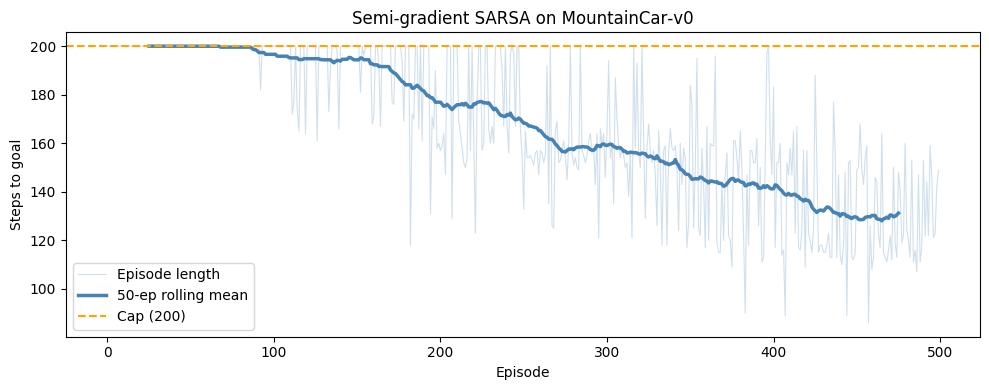

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ep_lengths, alpha=0.25, lw=0.8, color='steelblue', label='Episode length')
smoothed = np.convolve(ep_lengths, np.ones(50)/50, mode='valid')
ax.plot(np.arange(len(smoothed)) + 25, smoothed, color='steelblue', lw=2.5, label='50‑ep rolling mean')
ax.axhline(200, color='orange', lw=1.5, ls='--', label='Cap (200)')
ax.set_xlabel('Episode')
ax.set_ylabel('Steps to goal')
ax.set_title('Semi‑gradient SARSA on MountainCar‑v0')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Visualisation of the Learned Value Function and Policy

1. Create a grid over the state space.
2. Compute `max_a Q(s,a)` for each grid point.
3. Display the value function as a contour/heatmap and the policy as scatter markers.

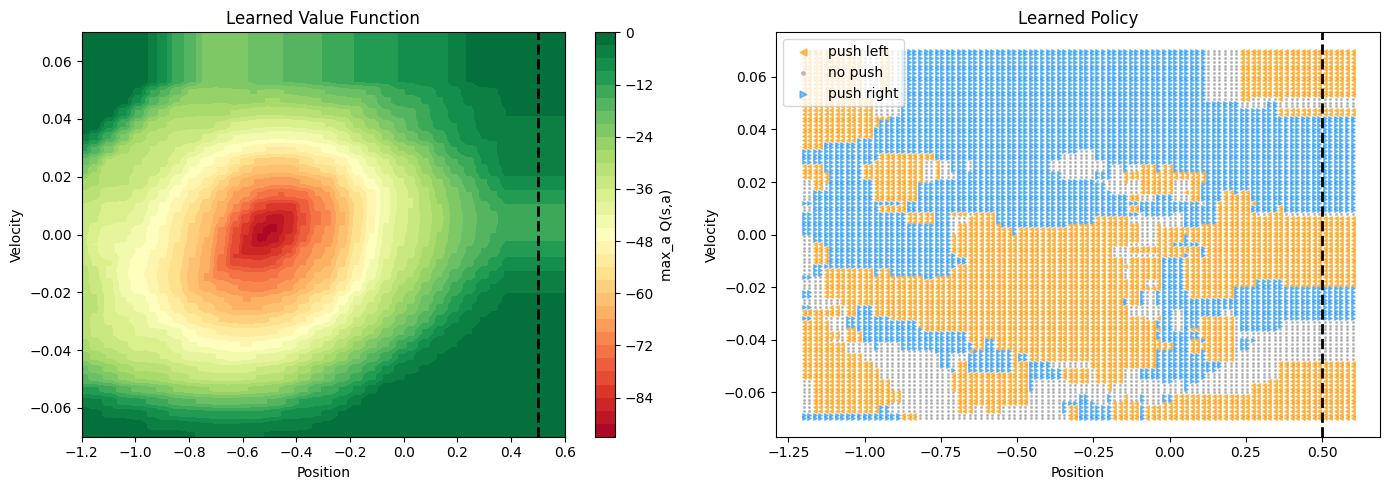

In [9]:
pos = np.linspace(-1.2, 0.6, 100)
vel = np.linspace(-0.07, 0.07, 100)
P, V = np.meshgrid(pos, vel)
V_vals = np.zeros_like(P)
A_vals = np.zeros_like(P, dtype=int)

for i in range(100):
    for j in range(100):
        state = [P[i, j], V[i, j]]
        qs = [weights[a] @ tile_coder.get_features(state) for a in range(3)]
        V_vals[i, j] = max(qs)
        A_vals[i, j] = int(np.argmax(qs))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5))

# value function
cf = ax0.contourf(P, V, V_vals, levels=30, cmap='RdYlGn')
fig.colorbar(cf, ax=ax0, label='max_a Q(s,a)')
ax0.axvline(0.5, color='black', lw=2, ls='--')
ax0.set_xlabel('Position')
ax0.set_ylabel('Velocity')
ax0.set_title('Learned Value Function')

# policy
colors = {0: '#FF9800', 1: '#9E9E9E', 2: '#2196F3'}
symbols = {0: '<', 1: '.', 2: '>'}
labels = {0: 'push left', 1: 'no push', 2: 'push right'}
for a in [0,1,2]:
    mask = (A_vals == a)
    ax1.scatter(P[mask], V[mask], c=colors[a], marker=symbols[a], s=6, alpha=0.6, label=labels[a])
ax1.axvline(0.5, color='black', lw=2, ls='--')
ax1.set_xlabel('Position')
ax1.set_ylabel('Velocity')
ax1.set_title('Learned Policy')
ax1.legend(markerscale=2)
plt.tight_layout()
plt.show()

## 4. Feature Design Experiments

Vary the tile‑coding parameters (number of tilings, tiles per dimension) and record the final performance.  
Explain how each change affects learning speed and the quality of the final policy.
**Hint:** You can wrap the experiment in a simple loop and store the average episode length of the last 50 episodes.

In [10]:
configs = [
    (8, [8, 8], 'default (8 tilings, 8×8)'),
    (4, [8, 8], '4 tilings'),
    (16, [8, 8], '16 tilings'),
    (8, [6, 6], '6×6 tiles'),
    (8, [10, 10], '10×10 tiles'),
    (1, [32, 32], '1 tiling, 32×32')
]

results = {}
for ntil, tpd, lbl in configs:
    _, lengths, _ = semi_gradient_sarsa(
        n_episodes=400,
        num_tilings=ntil,
        tiles_per_dim=tpd,
        alpha=0.1,
        seed=42,
        verbose=False
    )
    results[lbl] = np.mean(lengths[-50:])
    print(f'{lbl:30s}  → last 50‑ep avg: {results[lbl]:.0f} steps')

default (8 tilings, 8×8)        → last 50‑ep avg: 145 steps
4 tilings                       → last 50‑ep avg: 149 steps
16 tilings                      → last 50‑ep avg: 147 steps
6×6 tiles                       → last 50‑ep avg: 137 steps
10×10 tiles                     → last 50‑ep avg: 168 steps
1 tiling, 32×32                 → last 50‑ep avg: 200 steps


## 5. Observations & Discussion

### Why tabular methods fail for MountainCar
MountainCar has a continuous state space (position and velocity). Tabular methods, which require discretizing the state space into distinct, enumerable states, would face the curse of dimensionality. If we were to finely discretize the continuous states to capture enough detail for effective learning, the number of states would become astronomically large, making it impossible to store Q-values for every state-action pair and making learning extremely slow and inefficient due to insufficient visits to each state.

### How tile coding generalizes across the continuous state space
Tile coding addresses the continuous state space problem by creating a fixed number of overlapping "tilings" or grids. Each tiling discretizes the state space differently, with an offset from the others. When an agent is in a particular continuous state, it activates a small, fixed number of tiles (one per tiling). These active tiles represent a *feature vector*. Instead of learning a Q-value for an exact continuous state, the agent learns weights for these features. Since multiple nearby continuous states can activate *some* of the same tiles, information learned from one state can generalize to neighboring states. This provides a balance between generalization (due to overlapping tiles) and discrimination (due to unique combinations of active tiles).

### Effect of changing tile-coding parameters on learning speed and final performance
From the experiments, we observed:

*   **Number of Tilings:**
    *   **Default (8 tilings, 8x8):** Achieved an average of 145 steps in the last 50 episodes.
    *   **4 Tilings:** Performance was slightly worse at 149 steps. Fewer tilings mean less fine-grained generalization and potentially less overlap, leading to less robust value approximation.
    *   **16 Tilings:** Performed similarly to the default at 147 steps. More tilings increase the number of features activated per state, potentially offering richer representation and better generalization but also increasing the total number of features and thus the complexity of the weight update.

*   **Tile Resolution (Tiles per Dimension):**
    *   **Default (8x8 tiles):** 145 steps.
    *   **6x6 Tiles (coarser):** Showed the best performance at 137 steps. Coarser tiles lead to broader generalization, which can be beneficial in simpler environments or for faster initial learning, though it might sacrifice precision.
    *   **10x10 Tiles (finer):** Performed worse at 168 steps. Finer tiles reduce generalization and increase the total number of features. While theoretically more precise, it can lead to slower learning and overfitting if not enough experience is gathered for each fine tile combination.

*   **Extreme Cases:**
    *   **1 Tiling, 32x32:** This configuration performed the worst, reaching the `max_steps` cap at 200 steps. A single tiling offers no overlapping generalization between different grids, making it harder to learn. Increasing the tile resolution in a single tiling significantly increases the total features without the benefit of overlapping generalization across multiple tilings.

In general, a higher number of tilings and finer tile resolution increase the total number of features (`num_features`). While this can provide a more accurate representation of the value function, it also increases the computational cost and can lead to slower learning or divergence if the `alpha` (learning rate) is not appropriately scaled.

### Convergence Issues (alpha scaling)
As noted in the `semi_gradient_sarsa` implementation, the effective step size `alpha_eff` is calculated as `alpha / num_tilings`. This division is crucial for convergence. If `alpha` is not divided by `num_tilings`, the learning rate for each active feature becomes `alpha` instead of `alpha / num_tilings`. Since `num_tilings` features are active for any given state, the total update magnitude for the Q-value would be `num_tilings * alpha * td_error * x`. This effectively means the Q-values would be updated `num_tilings` times too aggressively, leading to large oscillations and often divergence (as indicated by the `diverged` flag in the `semi_gradient_sarsa` function if `weights` become non-finite). Proper scaling of `alpha` ensures that the sum of updates from all active features for a given state-action pair collectively amounts to an update of `alpha * td_error`.

---
*End of lab*